<a href="https://colab.research.google.com/github/NawtN/Students-performance-prediction-in-math-using-ML/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1-uplod the dataset

In [ ]:
# dataset uplod
from google.colab import files
uploaded = files.upload()


Saving student+performance.zip to student+performance.zip


2-import libraries

In [ ]:
import numpy as np
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import warnings
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


3-clean and load the student data

In [ ]:


def clean_student_data(df):
    df = df.drop_duplicates()
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()
    df = df[(df["G3"] >= 0) & (df["G3"] <= 20)]
    if df.isnull().sum().sum() > 0:
        df = df.fillna(method="ffill")
    return df


with zipfile.ZipFile("student+performance.zip", "r") as outer_zip:
    with outer_zip.open("student.zip") as inner_zip_file:
        with zipfile.ZipFile(inner_zip_file) as inner_zip:
            with inner_zip.open("student-mat.csv") as csv_file:
                data = pd.read_csv(csv_file, sep=";")
                print("Data loaded successfully.")
data = clean_student_data(data)

Data loaded successfully.


4- visual figures

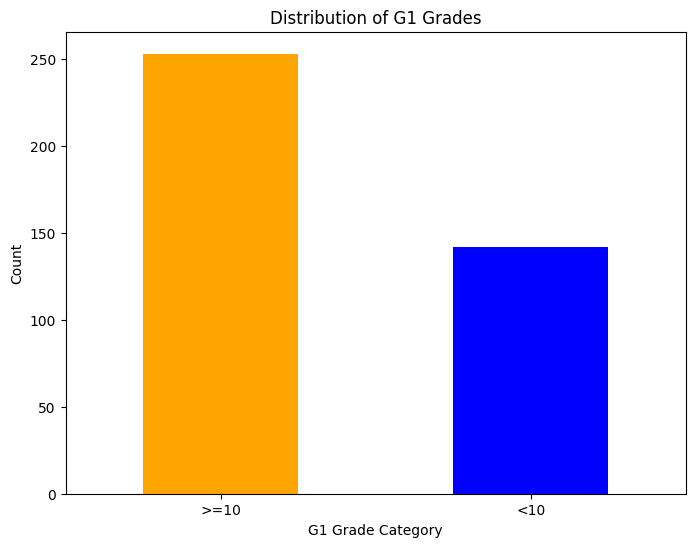

In [ ]:
# Visualize G1 distribution
data['G1_category'] = ['>=10' if g1 >= 10 else '<10' for g1 in data['G1']]
g1_category_counts = data['G1_category'].value_counts()
plt.figure(figsize=(8, 6))
g1_category_counts.plot(kind='bar', color=['orange', 'blue'])
plt.title('Distribution of G1 Grades')
plt.xlabel('G1 Grade Category')
plt.ylabel('Count')
plt.xticks([0, 1], ['>=10', '<10'], rotation=0)
plt.show()

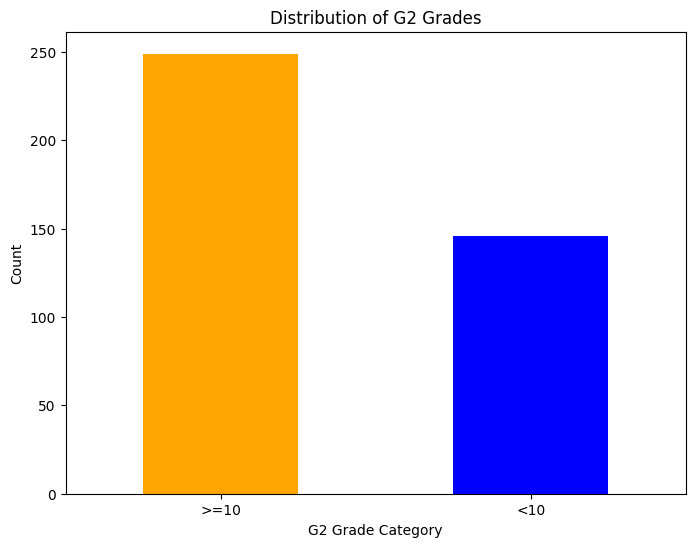

In [ ]:
# Visualize G2 distribution
data['G2_category'] = ['>=10' if g2 >= 10 else '<10' for g2 in data['G2']]
g1_category_counts = data['G2_category'].value_counts()
plt.figure(figsize=(8, 6))
g1_category_counts.plot(kind='bar', color=['orange', 'blue'])
plt.title('Distribution of G2 Grades')
plt.xlabel('G2 Grade Category')
plt.ylabel('Count')
plt.xticks([0, 1], ['>=10', '<10'], rotation=0)
plt.show()

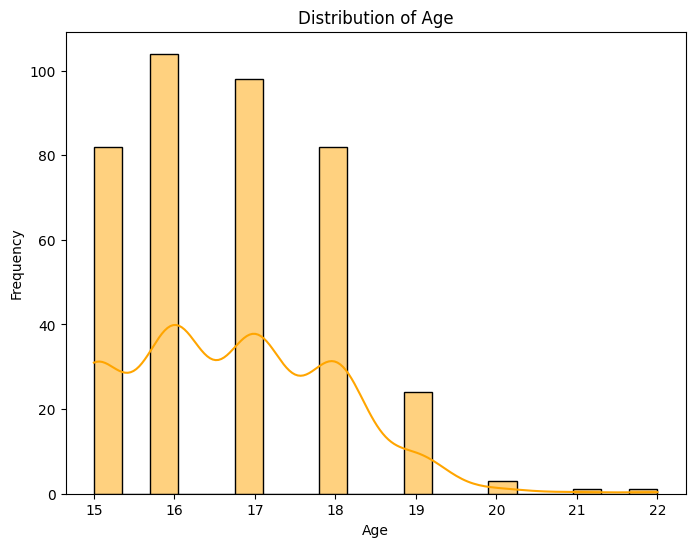

In [ ]:
# Visualize age distribution
plt.figure(figsize=(8, 6))
sns.histplot(data['age'], bins=20, kde=True, color='orange')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

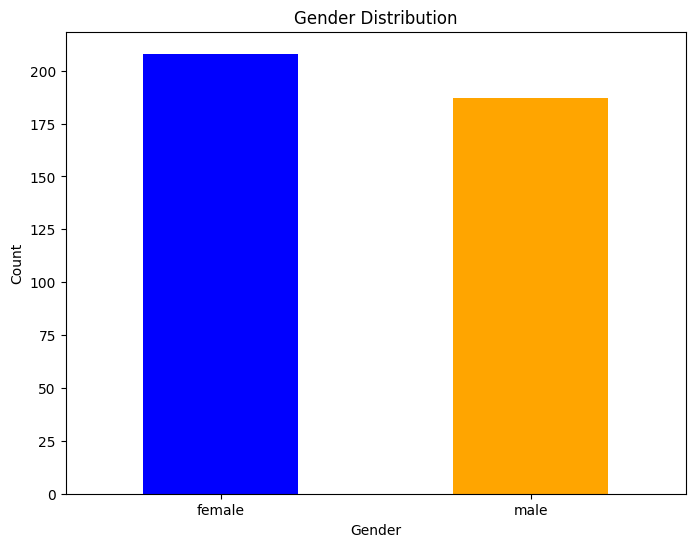

In [ ]:

# Visualize gender distribution
gender_counts = data['sex'].value_counts()
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks([0, 1], ['female', 'male'], rotation=0)
plt.show()


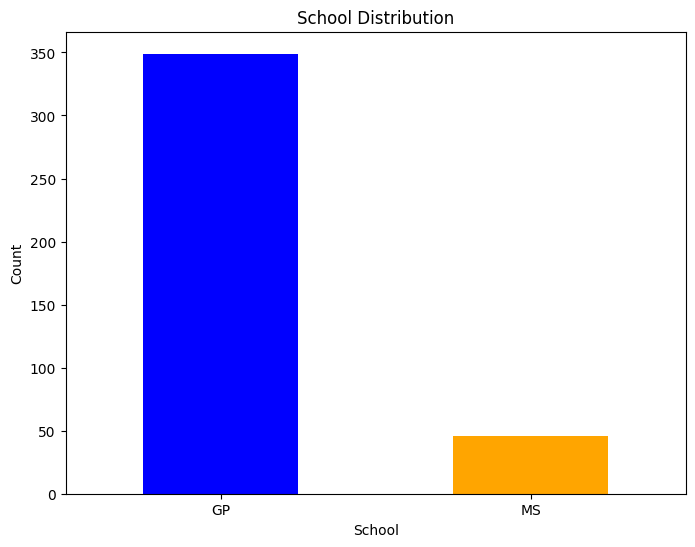

In [ ]:
# Visualize school distribution
school_counts = data['school'].value_counts()
plt.figure(figsize=(8, 6))
school_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('School Distribution')
plt.xlabel('School')
plt.ylabel('Count')
plt.xticks([0, 1], ['GP', 'MS'], rotation=0)
plt.show()


5-data Preprocessing

In [ ]:

# Encode categorical variables
categorical_columns = data.select_dtypes(include=["object"]).columns
# Create binary target
data[categorical_columns] = data[categorical_columns].apply(lambda x: pd.factorize(x)[0])
data["G3_cat"] = (data["G3"] >= 10).astype(int)
data.drop(columns=["G3"], inplace=True)

#Normalized all numerical features using Min-Max scaling:
X = data.drop(columns=["G3_cat"])
y = data["G3_cat"]
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


6-split the data

In [ ]:
 # First split: 70% train, 30% val+test
X_train, X_val_test, y_train, y_val_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Second split: 10% val, 20% test
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.667, random_state=42, stratify=y_val_test)

7-Train and Evaluate before pruning

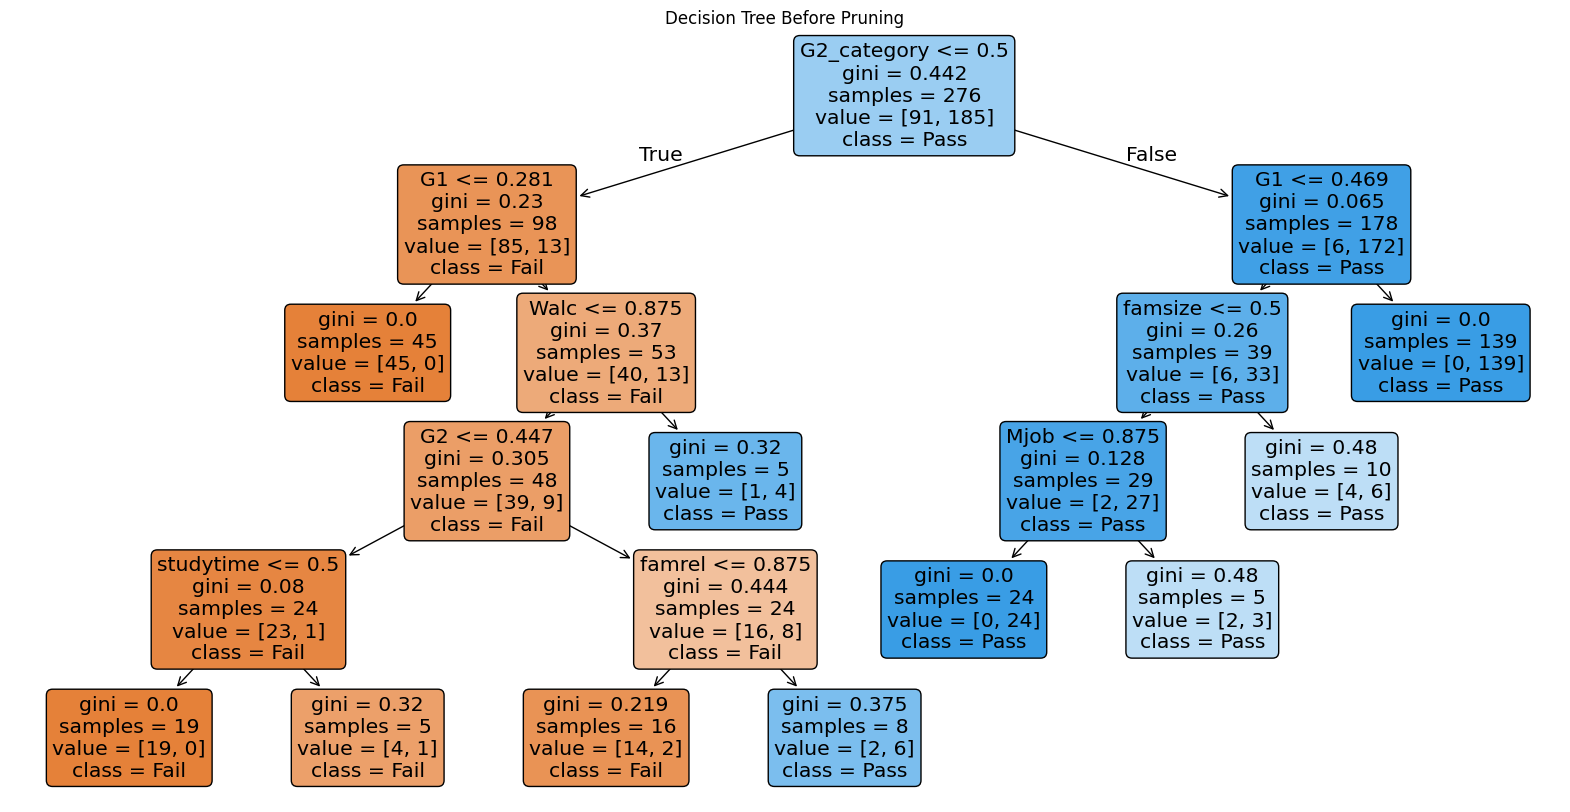

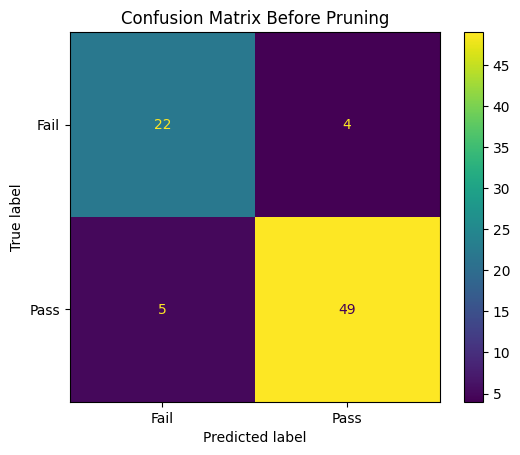


Accuracy on Test Set Before Pruning: 0.8875
Classification Report Before Pruning:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83        26
           1       0.92      0.91      0.92        54

    accuracy                           0.89        80
   macro avg       0.87      0.88      0.87        80
weighted avg       0.89      0.89      0.89        80



In [ ]:
clf = DecisionTreeClassifier(random_state=42, max_depth=None, min_samples_split=20, min_samples_leaf=5)
clf.fit(X_train, y_train)

# Plot tree before pruning
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True, rounded=True)
plt.title("Decision Tree Before Pruning")
plt.show()

# Evaluate before pruning
y_test_pred = clf.predict(X_test)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pred), display_labels=["Fail", "Pass"]).plot()
plt.title("Confusion Matrix Before Pruning")
plt.show()

print("\nAccuracy on Test Set Before Pruning:", accuracy_score(y_test, y_test_pred))
print("Classification Report Before Pruning:\n", classification_report(y_test, y_test_pred)) # Training after pruning



8-Train and Evaluate after pruning

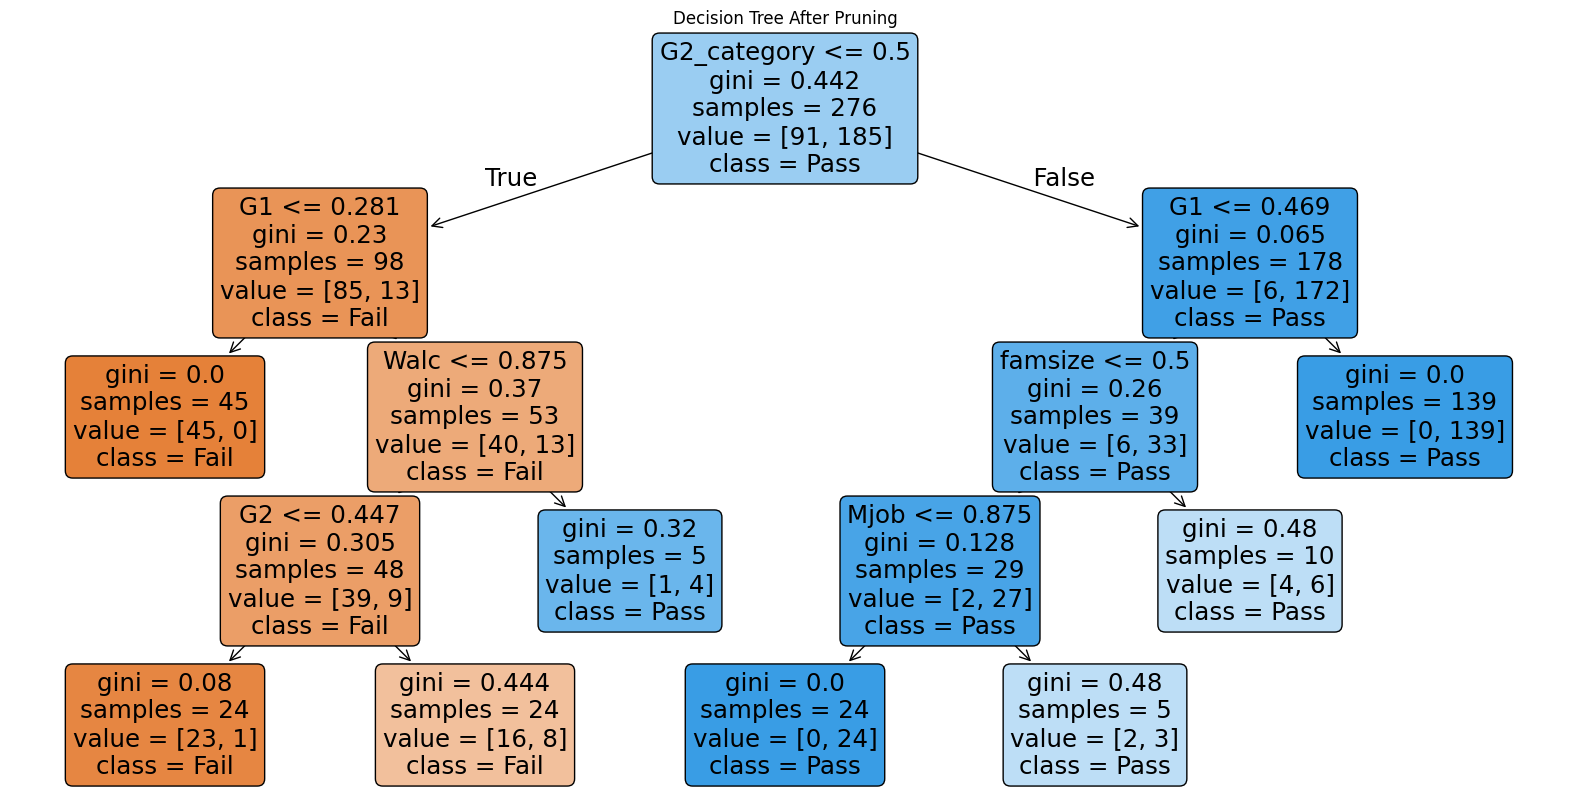

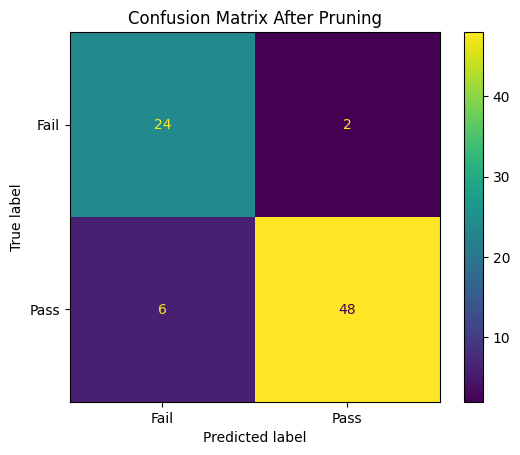


Accuracy on Test Set After Pruning: 0.9
Classification Report After Pruning:
               precision    recall  f1-score   support

           0       0.80      0.92      0.86        26
           1       0.96      0.89      0.92        54

    accuracy                           0.90        80
   macro avg       0.88      0.91      0.89        80
weighted avg       0.91      0.90      0.90        80



In [ ]:
# Using max_depth and min_samples_leaf for pruning
clf_pruned = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_split=20, min_samples_leaf=5)
clf_pruned.fit(X_train, y_train)

# Plot tree after pruning
plt.figure(figsize=(20, 10))
plot_tree(clf_pruned, feature_names=X.columns, class_names=["Fail", "Pass"], filled=True, rounded=True)
plt.title("Decision Tree After Pruning")
plt.show()

# Evaluate after pruning
y_test_pruned_pred = clf_pruned.predict(X_test)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_pruned_pred), display_labels=["Fail", "Pass"]).plot()
plt.title("Confusion Matrix After Pruning")
plt.show()

print("\nAccuracy on Test Set After Pruning:", accuracy_score(y_test, y_test_pruned_pred))
print("Classification Report After Pruning:\n", classification_report(y_test, y_test_pruned_pred))




9-**KNN**

9.1-Choosing K using cross-validation

In [ ]:
# Define the range of K values to test from 1 to 14
k_range = range(1, 15)

# Store the average cross-validation scores for each K
cv_scores = []

# Perform cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Find the optimal K and print it
best_k = k_range[cv_scores.index(max(cv_scores))]
print("optimal K:", best_k)

optimal K: 12


9.2-Train And Evaluate KNN

Accuracy on Test Set: 0.85
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.81      0.78        26
           1       0.90      0.87      0.89        54

    accuracy                           0.85        80
   macro avg       0.83      0.84      0.83        80
weighted avg       0.85      0.85      0.85        80



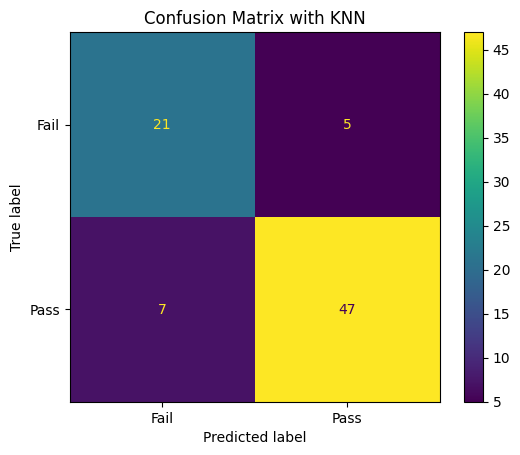

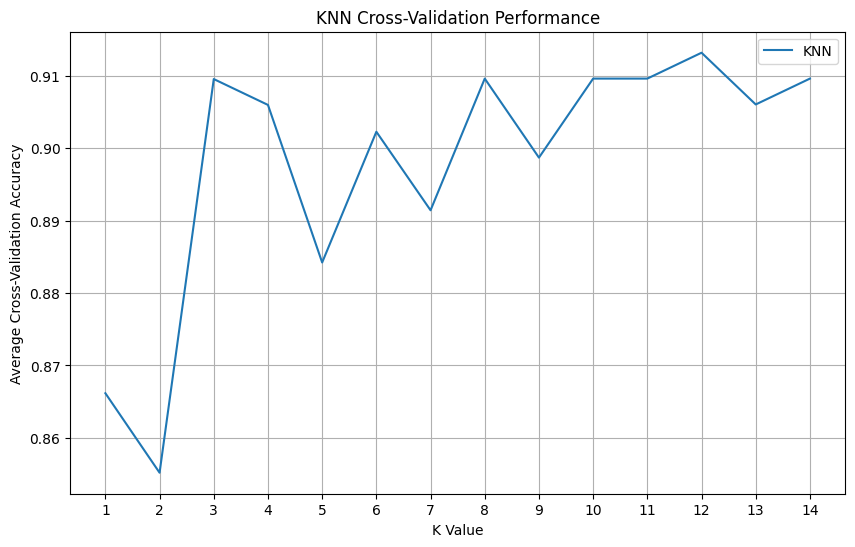

In [ ]:

# Train KNN with the optimal K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# Predict
y_test_knn_pred = knn.predict(X_test)


# Evaluate KNN accuracy and confusion matrix
print("Accuracy on Test Set:", accuracy_score(y_test, y_test_knn_pred))
print("Classification Report:\n", classification_report(y_test, y_test_knn_pred))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_knn_pred), display_labels=["Fail", "Pass"]).plot()
plt.title("Confusion Matrix with KNN")


# Plot the cross-validation results
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, label='KNN')
plt.xlabel('K Value')
plt.ylabel('Average Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Performance')
plt.legend()
plt.xticks(k_range)
plt.grid(True)
plt.show()



10-SVM

Best Parameters: {'C': 100, 'coef0': 0.0, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy on Test Set SVM: 0.8875
Classification Report SVM:
               precision    recall  f1-score   support

           0       0.77      0.92      0.84        26
           1       0.96      0.87      0.91        54

    accuracy                           0.89        80
   macro avg       0.87      0.90      0.88        80
weighted avg       0.90      0.89      0.89        80



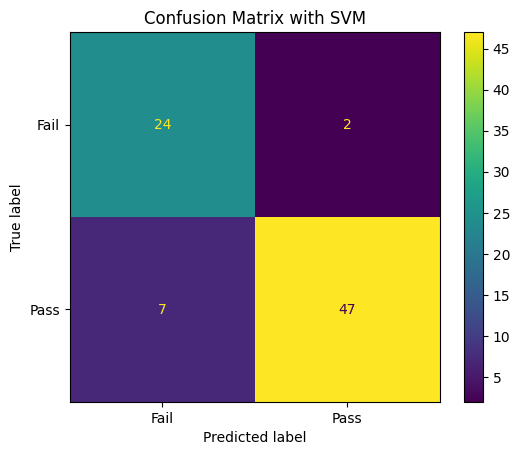

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10],
    'kernel': ['rbf'],
    'degree': [2, 3, 4],
    'coef0': [0.0, 0.1, 0.5],
}
# Create a GridSearchCV object
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_svm = grid_search.best_estimator_
y_test_svm_pred = best_svm.predict(X_test)

# Evaluate the SVM model
print("Accuracy on Test Set SVM:", accuracy_score(y_test, y_test_svm_pred))
print("Classification Report SVM:\n", classification_report(y_test, y_test_svm_pred))

# Plot the confusion matrix for SVM
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_svm_pred), display_labels=["Fail", "Pass"]).plot()
plt.title("Confusion Matrix with SVM")
plt.show()
